**Recovery note:** This notebook was reconstructed from an HTML export. The code, narrative, and visible outputs were preserved where possible.


<h1 id="Model-Development-&amp;-Evaluation">Model Development &amp; Evaluation<a class="anchor-link" href="#Model-Development-&amp;-Evaluation">¶</a></h1><p>This notebook develops and evaluates ETA prediction models using three validation strategies:</p>
<ol>
<li><strong>Random split</strong> – provides an initial baseline, but probably overestimates real-world performance because the same vessel and different points in time can appear in both training and testing sets.</li>
<li><strong>Grouped split by MMSI</strong> – evaluates generalisation to completely unseen vessels</li>
<li><strong>Time-based split</strong> – model only sees the past during training and is asked to predict the future.</li>
</ol>
<p>The same models and evaluation metrics are used for all three strategies to ensure a fair comparison.</p>


In [1]:
# Core libraries
import pandas as pd
import numpy as np

# Data splitting
from sklearn.model_selection import train_test_split, GroupShuffleSplit

# Models
from sklearn.linear_model import LinearRegression
from lightgbm import LGBMRegressor

# Evaluation metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Display settings
pd.set_option("display.max_columns", None)


In [2]:
# Load the modelling dataset with metadata

data = pd.read_csv(
    "../data/processed/model_data_with_metadata.csv",
    parse_dates=["recorded_at", "eta_datetime"]
)

print("Dataset shape:", data.shape)
data.head()


Dataset shape: (312059, 61)


,mmsi,nav_status,sog,cog,heading,lat,lon,draught,recorded_at,eta_datetime,remaining_hours,hour,day_of_week,month,is_weekend,manoeuvre_str_Nessuna manovra speciale,manoeuvre_str_Non disponibile,nav_status_str_In navigazione a motore,nav_status_str_In navigazione a vela,nav_status_str_Manovrabilità limitata,nav_status_str_Non definito,nav_status_str_Ormeggiata,nav_status_str_Vincolata dal pescaggio,destination_ITAUG,destination_ITCTA,destination_ITCTA>ITSAL,destination_ITGIT,destination_ITNAP,destination_ITSAL>ITCTA,destination_ITSIR,destination_ITSPA,destination_ITSPA FOR ORDERS,destination_MALTA,destination_MTMAR,destination_MTMLA,destination_MTMLA>ITCTA,destination_Other,destination_SANTA PANAGIA,destination_TRIST,destination_Unknown,ship_type_31,ship_type_37,ship_type_52,ship_type_54,ship_type_60,ship_type_69,ship_type_70,ship_type_71,ship_type_72,ship_type_73,ship_type_74,ship_type_75,ship_type_79,ship_type_80,ship_type_81,ship_type_82,ship_type_83,ship_type_84,ship_type_85,ship_type_89,ship_type_90
0,247190400,1.0,0.0,301.0,68.0,37.212332,15.205667,6.0,2026-04-03 10:42:38,2026-04-17 05:00:00,330.289444,10,4,4,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0
1,563205300,0.0,0.7,261.6,11.0,37.203918,15.537117,6.2,2026-04-03 10:42:38,2026-04-07 12:00:00,97.289444,10,4,4,0,0,1,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0
2,240788000,3.0,0.4,42.5,0.0,37.231985,15.556127,8.0,2026-04-03 10:42:38,2026-04-05 07:00:00,44.289444,10,4,4,0,0,1,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0
3,247055200,3.0,0.0,263.6,116.0,37.172913,15.201223,3.0,2026-04-03 10:42:38,2026-04-11 08:00:00,189.289444,10,4,4,0,0,1,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,240893000,1.0,0.0,310.0,50.0,37.119983,15.284300,15.2,2026-04-03 10:42:38,2026-04-19 23:00:00,396.289444,10,4,4,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0


In [16]:
print(f"Dataset shape: {data.shape}")
print(f"Missing values: {data.isna().sum().sum()}")
print(f"Duplicate rows: {data.duplicated().sum()}")
print(f"Date range: {data['recorded_at'].min()} to {data['recorded_at'].max()}")
print(f"Unique vessels: {data['mmsi'].nunique()}")


Dataset shape: (312059, 61)
Missing values: 0
Duplicate rows: 0
Date range: 2026-04-03 10:42:38 to 2026-04-16 12:43:53
Unique vessels: 369


In [ ]:
# Metadata (not used for model training)
metadata_columns = [
    "mmsi",
    "recorded_at",
    "eta_datetime"
]

# Predictor variables
X = data.drop(
    columns=metadata_columns + ["remaining_hours"]
)

# Target variable
y = data["remaining_hours"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

print("\nAll model features numeric:", all(X.dtypes.apply(lambda dtype: np.issubdtype(dtype, np.number))))


Features shape: (312059, 57)
Target shape: (312059,)

All model features numeric: True


<h3 id="Note">Note<a class="anchor-link" href="#Note">¶</a></h3><p>Excluded columns from the predictors . The resulting across all evaluation strategies.</p>


In [ ]:
def evaluate_models(X_train, X_test, y_train, y_test, evaluation_name):
    results = []
    models = {}
    predictions = {}

    # Linear Regression
    linear_model = LinearRegression(n_jobs=-1)
    linear_model.fit(X_train, y_train)

    linear_predictions = linear_model.predict(X_test)

    results.append({
        "Evaluation": evaluation_name,
        "Model": "Linear Regression",
        "MAE": mean_absolute_error(y_test, linear_predictions),
        "RMSE": np.sqrt(mean_squared_error(y_test, linear_predictions)),
        "R2": r2_score(y_test, linear_predictions)
    })

    models["Linear Regression"] = linear_model
    predictions["Linear Regression"] = linear_predictions

    # LightGBM
    lightgbm_model = LGBMRegressor(
        n_estimators=200,
        learning_rate=0.05,
        random_state=42,
        verbosity=-1
    )

    lightgbm_model.fit(X_train, y_train)

    lightgbm_predictions = lightgbm_model.predict(X_test)

    results.append({
        "Evaluation": evaluation_name,
        "Model": "LightGBM",
        "MAE": mean_absolute_error(y_test, lightgbm_predictions),
        "RMSE": np.sqrt(mean_squared_error(y_test, lightgbm_predictions)),
        "R2": r2_score(y_test, lightgbm_predictions)
    })

    models["LightGBM"] = lightgbm_model
    predictions["LightGBM"] = lightgbm_predictions

    results_df = pd.DataFrame(results)

    print(f"{evaluation_name} results")
    display(results_df.round({
        "MAE": 2,
        "RMSE": 2,
        "R2": 3
    }))

    return results, models, predictions


<h2 id="Note">Note<a class="anchor-link" href="#Note">¶</a></h2><p>A function that does the follwing:</p>
<ul>
<li>Trains Linear Regression.</li>
<li>Trains LightGBM.</li>
<li>Calculates MAE, RMSE, and R² for both models.</li>
</ul>


<h2 id="1.-Random-Train-Test-Split">1. Random Train-Test Split<a class="anchor-link" href="#1.-Random-Train-Test-Split">¶</a></h2><ul>
<li><p>The first evaluation uses the  standard random train-test split.</p>
</li>
<li><p>This provides an initial baseline</p>
</li>
<li><p>Same vessel and different points in time can appear in both the training and testing sets.</p>
</li>
</ul>


In [6]:
# Random train-test split

X_train_random, X_test_random, y_train_random, y_test_random = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training rows:", len(X_train_random))
print("Testing rows:", len(X_test_random))

random_results, random_models, random_predictions = evaluate_models(
    X_train_random,
    X_test_random,
    y_train_random,
    y_test_random,
    evaluation_name="Random Split"
)


Training rows: 249647
Testing rows: 62412
Random Split results


,Evaluation,Model,MAE,RMSE,R2
0,Random Split,Linear Regression,69.61,110.96,0.676
1,Random Split,LightGBM,25.43,36.68,0.965


<h3 id="Finding">Finding<a class="anchor-link" href="#Finding">¶</a></h3><p>LightGBM substantially outperformed Linear Regression</p>


<h2 id="2.-Grouped-Train-Test-Split-by-Vessel">2. Grouped Train-Test Split by Vessel<a class="anchor-link" href="#2.-Grouped-Train-Test-Split-by-Vessel">¶</a></h2><p>This method groups observations by vessel (MMSI), so that all observations from a given vessel appear exclusively in either the training or testing set.</p>
<p>This evaluates the model's ability to generalise to completely unseen vessels</p>


In [7]:
# Grouped train-test split by vessel

groups = data["mmsi"]

gss = GroupShuffleSplit(
    n_splits=1,
    test_size=0.20,
    random_state=42
)

train_idx, test_idx = next(gss.split(X, y, groups=groups))

X_train_group = X.iloc[train_idx]
X_test_group = X.iloc[test_idx]

y_train_group = y.iloc[train_idx]
y_test_group = y.iloc[test_idx]

print("Training rows:", len(X_train_group))
print("Testing rows:", len(X_test_group))

print("\nTraining vessels:", data.iloc[train_idx]["mmsi"].nunique())
print("Testing vessels:", data.iloc[test_idx]["mmsi"].nunique())

overlap = set(data.iloc[train_idx]["mmsi"]).intersection(
    set(data.iloc[test_idx]["mmsi"])
)

print("Vessel overlap:", len(overlap))

group_results, group_models, group_predictions = evaluate_models(
    X_train_group,
    X_test_group,
    y_train_group,
    y_test_group,
    evaluation_name="Grouped Split"
)


Training rows: 196798
Testing rows: 115261

Training vessels: 295
Testing vessels: 74
Vessel overlap: 0
Grouped Split results


,Evaluation,Model,MAE,RMSE,R2
0,Grouped Split,Linear Regression,111.83,152.95,-0.891
1,Grouped Split,LightGBM,109.70,143.88,-0.673


<h3 id="Finding">Finding<a class="anchor-link" href="#Finding">¶</a></h3><p>The grouped split produced substantially lower performance than the random split for both models</p>
<p>Unlike the random split, this evaluation prevents observations from the same vessel appearing in both the training and testing sets, resulting in a true evaluation on previously unseen vessels.</p>
<p>The large performance decrease indicates that the current variable chosen  generalises well to vessels already represented in the training data but struggles to predict completely unseen vessels</p>


<h3 id="Check-dates-to-prepare-for-the-third-method">Check dates to prepare for the third method<a class="anchor-link" href="#Check-dates-to-prepare-for-the-third-method">¶</a></h3>


In [20]:
date_counts = (
    data["recorded_at"]
    .dt.date
    .value_counts()
    .sort_index()
    .rename("rows")
    .to_frame()
)

date_counts


,rows
recorded_at,
2026-04-03,7814
2026-04-04,18027
2026-04-05,25949
2026-04-06,31614
2026-04-07,32170
2026-04-08,29920
2026-04-09,20582
2026-04-10,34596
2026-04-11,38865


<p>I used  12 April as the cutoff. Observations up to 11 April were used for training, while observations from 12–16 April were reserved for testing.</p>


<h2 id="3.-Chronological-Train-Test-Split">3. Chronological Train-Test Split<a class="anchor-link" href="#3.-Chronological-Train-Test-Split">¶</a></h2><p>The final evaluation uses a chronological split based on the observation timestamp (<code>recorded_at</code>).</p>
<p>The model is trained using historical observations up to 11 April 2026 and evaluated on observations collected afterwards. This prevents informatio leaking into the training data and it also reflects how an ETA prediction model would be deployed in practice.</p>


In [ ]:
cutoff_date = pd.Timestamp("2026-04-12")

train_mask = data["recorded_at"] < cutoff_date
test_mask = data["recorded_at"] >= cutoff_date

X_train_time = X.loc[train_mask]
X_test_time = X.loc[test_mask]

y_train_time = y.loc[train_mask]
y_test_time = y.loc[test_mask]

print("Training rows:", len(X_train_time))
print("Testing rows:", len(X_test_time))

print("\nTraining period:")
print(data.loc[train_mask, "recorded_at"].min(), "to",
      data.loc[train_mask, "recorded_at"].max())

print("\nTesting period:")
print(data.loc[test_mask, "recorded_at"].min(), "to",
      data.loc[test_mask, "recorded_at"].max())

time_results, time_models, time_predictions = evaluate_models(
    X_train_time,
    X_test_time,
    y_train_time,
    y_test_time,
    evaluation_name="Time Split"
)


Training rows: 239537
Testing rows: 72522

Training period:
2026-04-03 10:42:38 to 2026-04-11 23:59:03

Testing period:
2026-04-12 00:00:04 to 2026-04-16 12:43:53
Time Split results


,Evaluation,Model,MAE,RMSE,R2
0,Time Split,Linear Regression,104.33,175.50,0.441
1,Time Split,LightGBM,97.25,135.33,0.668


<h3 id="Findings">Findings<a class="anchor-link" href="#Findings">¶</a></h3><p>LightGBM again outperformed Linear Regression. Performance was lower than with the random split, which is expected because predicting future observations is a more challenging task.</p>


In [14]:
# Combine results from all evaluation strategies

comparison_results = pd.concat(
    [
        pd.DataFrame(random_results),
        pd.DataFrame(group_results),
        pd.DataFrame(time_results)
    ],
    ignore_index=True
)

comparison_results = comparison_results.round({
    "MAE": 2,
    "RMSE": 2,
    "R2": 3
})

comparison_results


,Evaluation,Model,MAE,RMSE,R2
0,Random Split,Linear Regression,69.61,110.96,0.676
1,Random Split,LightGBM,25.43,36.68,0.965
2,Grouped Split,Linear Regression,111.83,152.95,-0.891
3,Grouped Split,LightGBM,109.70,143.88,-0.673
4,Time Split,Linear Regression,104.33,175.50,0.441
5,Time Split,LightGBM,97.25,135.33,0.668


<h3 id="Conclusion">Conclusion<a class="anchor-link" href="#Conclusion">¶</a></h3><ul>
<li>Random split is the easiest evaluation.</li>
<li>Time split is harder but still performs reasonably well.</li>
<li>Grouped split is the hardest because vessels in the test set were never seen during training.</li>
</ul>


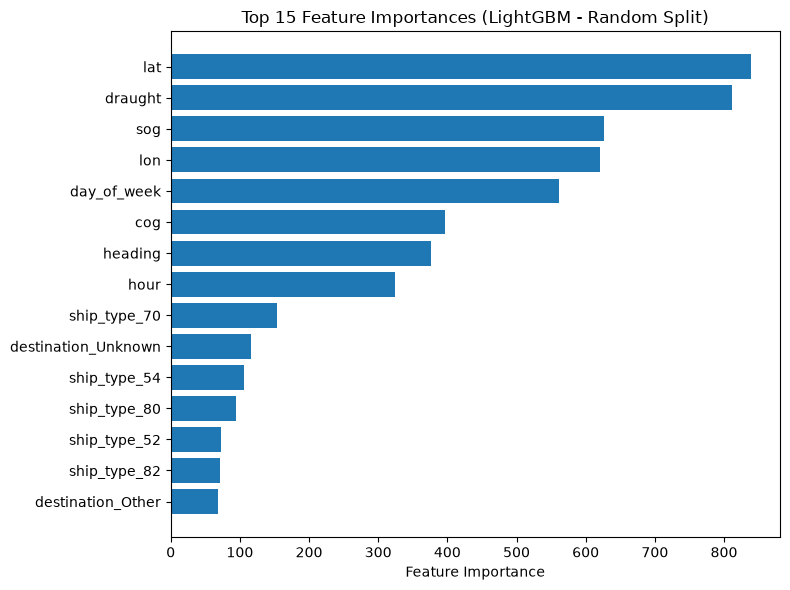

In [15]:
import matplotlib.pyplot as plt

# Feature importance from the best-performing model (LightGBM - Random Split)
best_model = random_models["LightGBM"]

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": best_model.feature_importances_
})

top_features = (
    feature_importance
    .sort_values("Importance", ascending=False)
    .head(15)
)

plt.figure(figsize=(8, 6))
plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.xlabel("Feature Importance")
plt.title("Top 15 Feature Importances (LightGBM - Random Split)")
plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()


<h3 id="Note">Note<a class="anchor-link" href="#Note">¶</a></h3><ul>
<li>Latitude ..	Indicates where the vessel is along its route.</li>
<li>Longitude .. Completes the vessel's current location.</li>
<li>SOG	 .. Shows how fast the vessel is currently moving.</li>
<li>Draught .. Reflects vessel loading and operating constraints, which can affect speed and routing.</li>
</ul>
